### chap-4. 신경망 학습(딥러닝)

##### 신경망 학습은 가중치 매개변수의 값(가중치와 편향)을 **데이터**를 보고 자동으로 결정한다.

##### 오버피팅을 피하기 위해 학습 데이터와 시험 데이터를 나눈다.


---

### 4-2. 손실 함수

###### 학습을 가장 좋게 만들어주는 매개변수 값의 지표

1. 평균 제곱 오차


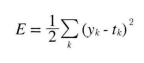

In [3]:
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0] # 원-핫 인코딩, 정답이 2
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

mean_squared_error(np.array(y), np.array(t))

np.float64(0.09750000000000003)

2. 교차 엔트로피 오차(cross entropy error)


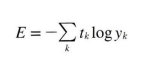

- t_K가 원-핫 인코딩이기 때문에 정답일 때의 출력이 전체 값을 정하게 된다.

In [6]:
import numpy as np

def cross_entropy_error(y, t):

    delta = 1e-7
    return -np.sum(t * np.log(y + delta)) # 아주 작은 delta를 더함으로써 y가 0일 때 log가 -무한대로 가는 것을 막아준다.


t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]

cross_entropy_error(np.array(y), np.array(t))

np.float64(2.302584092994546)

- *미니배치 학습: 훈련 데이터 중에서 일부를 뽑아 학습시키는 것.

In [ ]:
# 미니배치 학습
import sys, os
sys.path.append(os.pardir) 
import numpy as np
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(normalize = True, one_hot_label = True)

train_size = x_train.shape[0] # 60000장인 거를 저장
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size) # 0이상 60000 미만의 수 중에서 무작위로 10개 뽑기
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

#118